## DSRP - Machine Learning III

In [84]:
# Clasificación
from sklearn.metrics import accuracy_score, classification_report, recall_score, f1_score, auc, precision_score, roc_curve, roc_auc_score

# Regresión
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from loguru import logger

import dagshub
import mlflow

dagshub.init(repo_owner='davidrodriguez2712', repo_name='ml-3-modulo', mlflow=True)

Initialized MLflow to track repo "davidrodriguez2712/ml-3-modulo"

Repository davidrodriguez2712/ml-3-modulo initialized!

In [62]:
dagshub.init(repo_owner='davidrodriguez2712', repo_name='ml-3-modulo', mlflow=True)

Initialized MLflow to track repo "davidrodriguez2712/ml-3-modulo"

Repository davidrodriguez2712/ml-3-modulo initialized!

#### Métricas Clasificación

In [10]:
bank_marketing_raw_data = pd.read_csv('../data/bank-marketing.csv')

In [11]:
bank_marketing_raw_data.head()

,age,age group,eligible,job,salary,marital,education,marital-education,targeted,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,response
0,58,5,Y,management,100000,married,tertiary,married-tertiary,yes,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,4,Y,technician,60000,single,secondary,single-secondary,yes,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,3,Y,entrepreneur,120000,married,secondary,married-secondary,yes,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,4,Y,blue-collar,20000,married,unknown,married-unknown,no,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,3,Y,unknown,0,single,unknown,single-unknown,no,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


In [17]:
bank_marketing_raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                45211 non-null  int64 
 1   age group          45211 non-null  int64 
 2   eligible           45211 non-null  object
 3   job                45211 non-null  object
 4   salary             45211 non-null  int64 
 5   marital            45211 non-null  object
 6   education          45211 non-null  object
 7   marital-education  45211 non-null  object
 8   targeted           45211 non-null  object
 9   default            45211 non-null  object
 10  balance            45211 non-null  int64 
 11  housing            45211 non-null  object
 12  loan               45211 non-null  object
 13  contact            45211 non-null  object
 14  day                45211 non-null  int64 
 15  month              45211 non-null  object
 16  duration           45211 non-null  int64

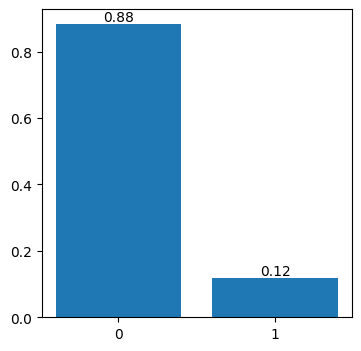

In [42]:
fig, ax = plt.subplots(1, 1, figsize= (4, 4))
bars = ax.bar(
    x= [0, 1],
    height= bank_marketing_raw_data['response'].value_counts(normalize= True)
)
ax.bar_label(bars, fmt= '%.2f')
ax.set_xticks(ticks= [0, 1])

plt.show()

In [64]:
CLASSIFICATION_FEATURES = ['age', 'balance', 'salary']
CLASSIFICATION_RESPONSE = "response"

X = bank_marketing_raw_data[CLASSIFICATION_FEATURES]
y = bank_marketing_raw_data[CLASSIFICATION_RESPONSE]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y, random_state= 1, test_size = 0.25)


In [ ]:
classifier = GradientBoostingClassifier()
classifier.fit(X_train_clf, y_train_clf)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [65]:
predictions_gbt = classifier.predict(X_test_clf)
probabilities_gbt = classifier.predict_proba(X_test_clf)

<Axes: >

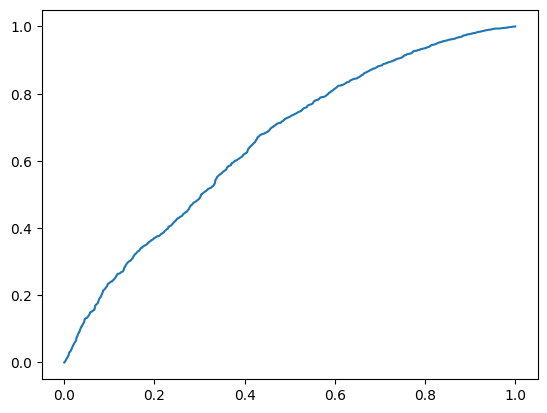

In [ ]:
tpr, fpr, _ = roc_curve(y_true= y_train_clf, y_score= probabilities_gbt[:, 0], pos_label= 1)

sns.lineplot(x = fpr, y= tpr)

In [49]:
auc(fpr, tpr)

0.6582241352485056

In [50]:
def calculate_classification_metrics(y_real, predictions) -> dict:
    """
    Calcula métricas de clasificación
    """
    return {
        'accuracy': accuracy_score(y_real, predictions),
        'precision': precision_score(y_real, predictions),
        'recall': recall_score(y_real, predictions),
        'f1_score': f1_score(y_real, predictions),
        'auc_score': roc_auc_score(predictions_gbt, y_real)
    }

calculate_classification_metrics(y_real= y_test, predictions= predictions_gbt)

{'accuracy': 0.8841900380429975,
 'precision': 0.43333333333333335,
 'recall': 0.00996168582375479,
 'f1_score': 0.01947565543071161,
 'auc_score': 0.6593616014666313}

#### Métricas Regresión

In [12]:
lift_raw_data = pd.read_csv('../data/Lyftdataset.csv')

In [13]:
lift_raw_data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-11,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,01-01-11,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,01-01-11,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,01-01-11,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,01-01-11,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [53]:
lift_raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [60]:
lift_raw_data.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [66]:
REGRESSION_FEATURES = ['temp', 'hum', 'holiday']
REGRESSION_RESPONSE = "cnt"

X = lift_raw_data[REGRESSION_FEATURES]
y = lift_raw_data[REGRESSION_RESPONSE]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y, random_state = 1, test_size = 0.25)

In [ ]:
regressor = GradientBoostingRegressor()
regressor.fit(X_train_reg, y_train_reg)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [ ]:
predictions_rgbt = regressor.predict(X_test_reg)

In [ ]:
def calculate_regression_metrics(y_real, predictions) -> dict:
    """
    Calculo de métricas de regresión
    """
    return {
        'mse': mean_squared_error(y_real, predictions),
        'rmse': mean_squared_error(y_real, predictions) ** 0.5,
        'mae': mean_absolute_error(y_real, predictions),
        'mape': mean_absolute_percentage_error(y_real, predictions)
    }

calculate_regression_metrics(y_test_reg, predictions_rgbt)

{'mse': 24251.10095798306,
 'rmse': 155.72764994689626,
 'mae': 115.79182832774141,
 'mape': 4.932979153756281}

## Optimización

In [98]:
from hyperopt import fmin, tpe, space_eval, Trials, STATUS_OK, hp
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import optuna

In [91]:
class AIOptimizer:
    def __init__(self, opt_strategy: str, search_space, algorithm) -> None:
        self.strategy = opt_strategy
        self.search_space = search_space
        self.algorithm = algorithm

    def optimize(self):

        if self.strategy == 'grid_search':
            gs_classifier = GridSearchCV(
                estimator = self.algorithm,
                param_grid= self.search_space,
                cv = 5,
                scoring = 'accuracy'
            )
            gs_classifier.fit(X_train_clf, y_train_clf)
            logger.info(f'Best Score {gs_classifier.best_score_}')
            logger.info(f'Best Params {gs_classifier.best_params_}')
            return (
                gs_classifier.best_estimator_,
                gs_classifier.best_score_,
                gs_classifier.best_params_
            )
        elif self.strategy == 'random_search':
            rs_classifier = RandomizedSearchCV(
                estimator = self.algorithm,
                param_distributions = self.search_space,
                cv = 3,
                scoring = "accuracy",
                n_iter= 5
            )
            rs_classifier.fit(X_train_clf, y_train_clf)
            logger.info(f'Best Score {rs_classifier.best_score_}')
            logger.info(f'Best Params {rs_classifier.best_params_}')
            return (
                rs_classifier.best_estimator_,
                rs_classifier.best_score_,
                rs_classifier.best_params_
            )

### GridSearch

In [118]:
with mlflow.start_run(run_name = 'gridsearch') as run:


    # Espacio de búsqueda (Utilizando GridSearchCV)
    gridsearch_params = {
        'loss': ('log_loss', 'exponential'),
        'learning_rate': [0.1, 0.5],
        'n_estimators': [10, 100]
    }
    # classifier = GradientBoostingClassifier()
    # gs_classifier = GridSearchCV(estimator = classifier, param_grid = gridsearch_params, cv= 5, scoring= "accuracy")
    # gs_classifier.fit(X_train_clf, y_train_clf)
    optimizer = AIOptimizer(
        opt_strategy = 'grid_search',
        search_space = gridsearch_params,
        algorithm = classifier
    )
    _, score, params = optimizer.optimize()

    mlflow.log_metric('accuracy', score)
    mlflow.log_params(params)

2026-04-24 14:31:16.641 | INFO     | __main__:optimize:17 - Best Score 0.8825645850456183
2026-04-24 14:31:16.641 | INFO     | __main__:optimize:18 - Best Params {'learning_rate': 0.1, 'loss': 'log_loss', 'n_estimators': 10}


🏃 View run gridsearch at: https://dagshub.com/davidrodriguez2712/ml-3-modulo.mlflow/#/experiments/0/runs/b7012d927eb0493eafa1dd27eaa31a6a
🧪 View experiment at: https://dagshub.com/davidrodriguez2712/ml-3-modulo.mlflow/#/experiments/0


In [86]:
optimizer = AIOptimizer(
    opt_strategy = "grid_search",
    search_space = gridsearch_params,
    algorithm = classifier
)
optimizer.optimize()

2026-04-23 12:28:56.192 | INFO     | __main__:optimize:17 - Best Score 0.8826530545236484
2026-04-23 12:28:56.193 | INFO     | __main__:optimize:18 - Best Params {'learning_rate': 0.1, 'loss': 'exponential', 'n_estimators': 50}


(GradientBoostingClassifier(loss='exponential', n_estimators=50),
 np.float64(0.8826530545236484),
 {'learning_rate': 0.1, 'loss': 'exponential', 'n_estimators': 50})

In [75]:
gs_classifier.best_params_

{'learning_rate': 0.1, 'loss': 'exponential', 'n_estimators': 50}

In [76]:
gs_classifier.best_score_

np.float64(0.8826530545236484)

### RandomizedSearchCV

In [ ]:
# Espacio de búsqueda (Utilizando RandomizedSearchCV)
randomsearch_params = {
    'loss': ['log_loss', 'exponential'],
    'learning_rate': [0.1, 0.001, 0.5],
    'n_estimators': [10, 50, 100],
    'min_samples_split': [2, 5, 10],
    'max_depth': [2, 5, 3, 8]
}
classifier = GradientBoostingClassifier()
rs_classifier = RandomizedSearchCV(estimator = classifier, param_distributions= randomsearch_params, cv= 5, scoring= "accuracy", n_iter= 5)
rs_classifier.fit(X_train_clf, y_train_clf)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.1, 0.001, ...], 'loss': ['log_loss', 'exponential'], 'max_depth': [2, 5, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [120]:
with mlflow.start_run(run_name = 'randomizedsearch') as run:
    randomsearch_params = {
        'loss': ('log_loss', 'exponential'),
        'min_samples_split': [2, 5, 10],
        'max_depth': [3, 5, 10],
        'n_estimators': [10, 50, 100],
        'learning_rate': [0.1, 0.001, 0.5]
    }

    classifier = GradientBoostingClassifier()
    
    optimizer = AIOptimizer(
        opt_strategy = 'random_search',
        search_space = randomsearch_params,
        algorithm = classifier
    )
    best_estimator, score, params = optimizer.optimize()

    mlflow.log_metric('accuracy', score)
    mlflow.log_params(params)

2026-04-24 14:41:07.342 | INFO     | __main__:optimize:33 - Best Score 0.8825056110210431
2026-04-24 14:41:07.342 | INFO     | __main__:optimize:34 - Best Params {'n_estimators': 10, 'min_samples_split': 2, 'max_depth': 5, 'loss': 'log_loss', 'learning_rate': 0.1}


🏃 View run randomizedsearch at: https://dagshub.com/davidrodriguez2712/ml-3-modulo.mlflow/#/experiments/0/runs/15a6796102414d06b26100b41d7ebc4f
🧪 View experiment at: https://dagshub.com/davidrodriguez2712/ml-3-modulo.mlflow/#/experiments/0


In [82]:
rs_classifier.best_params_

{'n_estimators': 50,
 'min_samples_split': 2,
 'max_depth': 8,
 'loss': 'exponential',
 'learning_rate': 0.001}

In [83]:
rs_classifier.best_score_

np.float64(0.8825056053935982)

In [92]:
optimizer = AIOptimizer(
    opt_strategy = 'random_search',
    search_space = randomsearch_params,
    algorithm = classifier
)
optimizer.optimize()

2026-04-23 12:35:59.219 | INFO     | __main__:optimize:33 - Best Score 0.8826235685851165
2026-04-23 12:35:59.220 | INFO     | __main__:optimize:34 - Best Params {'n_estimators': 50, 'min_samples_split': 5, 'max_depth': 2, 'loss': 'log_loss', 'learning_rate': 0.1}


(GradientBoostingClassifier(max_depth=2, min_samples_split=5, n_estimators=50),
 np.float64(0.8826235685851165),
 {'n_estimators': 50,
  'min_samples_split': 5,
  'max_depth': 2,
  'loss': 'log_loss',
  'learning_rate': 0.1})

## TPE / Hyperopt

In [95]:
tpe_search_space = {
    'loss': hp.choice('log', ['log_loss', 'exponential']),
    'learning_rate': hp.normal('learning_rate', 0.1, 0.01),
    'n_estimators': hp.quniform('n_estimators', 10, 100, 10),
    'min_samples_split': hp.quniform('min_samples_split', 2, 10, 1),
    'max_depth': hp.quniform('max_depth', 3, 20, 1)
}

def objective(params):
    # params -> accuracy -> {más alto posible}

    adj_params = {
        'loss': params['loss'],
        'learning_rate': params['learning_rate'],
        'n_estimators': int(params['n_estimators']),
        'min_samples_split': int(params['min_samples_split']),
        'max_depth': int(params['max_depth'])
    }

    classifier = GradientBoostingClassifier(**adj_params)
    classifier.fit(X_train_clf, y_train_clf)
    predictions = classifier.predict(X_test_clf)
    _accuracy = accuracy_score(y_test_clf, predictions)

    return {
        'loss': 1 - _accuracy,
        'status': STATUS_OK
    }

trials = Trials()
best = fmin(
    fn = objective,
    space= tpe_search_space,
    algo = tpe.suggest,
    max_evals = 10,
    trials = trials,
)

100%|██████████| 10/10 [00:23<00:00,  2.38s/trial, best loss: 0.11501371317349374]


In [96]:
best

{'learning_rate': np.float64(0.09331830925039991),
 'log': np.int64(0),
 'max_depth': np.float64(4.0),
 'min_samples_split': np.float64(4.0),
 'n_estimators': np.float64(100.0)}

In [97]:
best_params = space_eval(tpe_search_space, best)

best_params = {
    'loss': best_params['loss'],
    'learning_rate': best_params['learning_rate'],
    'n_estimators': int(best_params['n_estimators']),
    'min_samples_split': int(best_params['min_samples_split']),
    'max_depth': int(best_params['max_depth'])
}

classifier = GradientBoostingClassifier(**best_params)
classifier.fit(X_train_clf, y_train_clf)
predictions = classifier.predict(X_test_clf)
logger.info(f"Best Model Accuracy {accuracy_score(y_test_clf, predictions)}")

2026-04-24 13:46:31.287 | INFO     | __main__:<module>:14 - Best Model Accuracy 0.8849862868265063


## Optuna

In [ ]:
def objective_optuna(trial):
    # params -> accuracy -> (lo más alto posible)

    params = {
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'loss': trial.suggest_categorical('loss', ['log_loss', 'exponential'])
    }

    # params = {
    #     'loss': trial.suggest,
    #     'learning_rate': params['learning_rate'],
    #     'n_estimators': int(params['n_estimators']),
    #     'min_samples_split': int(params['min_samples_split']),
    #     'max_depth': int(params['max_depth'])
    # }

    classifier = GradientBoostingClassifier(**params)
    classifier.fit(X_train_clf, y_train_clf)
    predictions = classifier.predict(X_test_clf)
    _accuracy = accuracy_score(y_test_clf, predictions)

    return 1 - _accuracy

study = optuna.create_study(
    direction = "minimize",
    sampler = optuna.samplers.TPESampler()
)

study.optimize(objective_optuna, n_trials = 10)

In [100]:
study.best_params

{'max_depth': 5}

In [102]:
1- study.best_value

0.8848978147394497

In [124]:
with mlflow.start_run(run_name = 'tpe_optuna') as run:

    
    study = optuna.create_study(
    direction = "minimize",
    sampler = optuna.samplers.TPESampler()
    )
    study.optimize(objective_optuna, n_trials = 10)

    mlflow.log_metric('accuracy', 1 - study.best_value)
    mlflow.log_params(study.best_params)

[I 2026-04-24 14:51:02,109] A new study created in memory with name: no-name-f6f2cd58-aad3-4f62-b80e-dfbd404fb221
[I 2026-04-24 14:51:11,323] Trial 0 finished with value: 0.12695744492612582 and parameters: {'max_depth': 17, 'loss': 'log_loss'}. Best is trial 0 with value: 0.12695744492612582.
[I 2026-04-24 14:51:20,658] Trial 1 finished with value: 0.12217995222507294 and parameters: {'max_depth': 17, 'loss': 'exponential'}. Best is trial 1 with value: 0.12217995222507294.
[I 2026-04-24 14:51:32,194] Trial 2 finished with value: 0.13261965849774393 and parameters: {'max_depth': 19, 'loss': 'log_loss'}. Best is trial 1 with value: 0.12217995222507294.
[I 2026-04-24 14:51:40,260] Trial 3 finished with value: 0.1238609218791471 and parameters: {'max_depth': 16, 'loss': 'log_loss'}. Best is trial 1 with value: 0.12217995222507294.
[I 2026-04-24 14:51:47,504] Trial 4 finished with value: 0.11846412456869859 and parameters: {'max_depth': 15, 'loss': 'exponential'}. Best is trial 4 with valu

🏃 View run tpe_optuna at: https://dagshub.com/davidrodriguez2712/ml-3-modulo.mlflow/#/experiments/0/runs/dabcc18db2c54941b4686c09e967bcd4
🧪 View experiment at: https://dagshub.com/davidrodriguez2712/ml-3-modulo.mlflow/#/experiments/0


## Algoritmos evolutivos

In [113]:
from sklearn_genetic import GASearchCV
from sklearn_genetic.space import Categorical, Integer, Continuos

ModuleNotFoundError: No module named 'sklearn_genetic'

In [ ]:
## Problema de compatibilidad con feast en la librería dill (feast usa 0.3.7 y genetic usa 0.4.1)
ga_search_space = {
    'loss': Categorical(['log_loss', 'exponential']),
    'learning_rate': Continuos(0.001, 1, distribution= 'uniform'),
    'n_estimators': Integer(10, 100),
    'max_depth': Integer(2, 10),
    'max_depth': Integer(3, 20)
}

evolution_classifier = GASearchCV(
    estimator = classifier,
    scoring = 'accuracy',
    param_grid = ga_search_space,
    population_size = 10,
    generations = 5,
    verbose = True
)

evolution_classifier.fit(X_train_clf, y_train_clf)